# SHAP, Feature Importance & ROC / PRG — E3\_pole\_tower

**Purpose:** Run SHAP analysis, extract XGBoost feature importance, and
produce publication-quality evaluation plots for the **E3\_pole\_tower**
experiment (pole\_density + tower\_density, 6-year training window).

| Section | Content |
|--------:|---------|
| 0–3 | Configuration, imports, data loading, feature list |
| 4 | Re-predict all water years from saved models |
| 5–8 | ROC curve, PR-Gain curve, AUC time-series, top-risk PG/RG |
| 9–12 | SHAP computation, feature importance |
| 13–16 | Visualisation — bar charts, heatmap, dependence plots |

## 0. Configuration

All editable paths and experiment parameters live in this single cell.
Change `EXP_NAME` / `LEN_TRAIN` to point at a different saved run.

In [1]:
import os

# ======================== PATHS ========================
DATA_ROOT    = r"E:\zcao\CA_Wildfire"
DATA_VERSION = "Monthly_03152026_calibration"
DATA_DIR     = os.path.join(DATA_ROOT, "Clean_Data", "Model_Data",
                            "Evaluation", "Features_w_Label", DATA_VERSION)

PROJECT_ROOT = r"E:\zcao\Ignition - ML Modeling"

# ---------- Experiment to analyse ----------
EXP_NAME    = "E3_pole_tower"
LEN_TRAIN   = 6
TAG         = f"{EXP_NAME}__LT{LEN_TRAIN}"

MODEL_DIR   = os.path.join(PROJECT_ROOT, "Models", TAG)
RESULTS_DIR = os.path.join(PROJECT_ROOT, "Results")
PLOT_DIR    = os.path.join(PROJECT_ROOT, "Plots", TAG)
SUMMARY_DIR = os.path.join(PROJECT_ROOT, "Summary_Data", TAG)

for d in [RESULTS_DIR, PLOT_DIR, SUMMARY_DIR]:
    os.makedirs(d, exist_ok=True)

# =================== GLOBALS ===================
LABEL_COL     = "IS_FIRE"
PREDICT_YEARS = list(range(2001, 2021))
RANDOM_STATE  = 42

# ======================== QA ========================
print(f"Data dir  : {DATA_DIR}")
print(f"Model dir : {MODEL_DIR}")
print(f"  [{'OK' if os.path.isdir(DATA_DIR) else 'MISSING'}] DATA_DIR")
print(f"  [{'OK' if os.path.isdir(MODEL_DIR) else 'MISSING'}] MODEL_DIR")

Data dir  : E:\zcao\CA_Wildfire\Clean_Data\Model_Data\Evaluation\Features_w_Label\Monthly_03152026_calibration
Model dir : E:\zcao\Ignition - ML Modeling\Models\E3_pole_tower__LT6
  [OK] DATA_DIR
  [OK] MODEL_DIR


## 1. Imports

In [2]:
import sys, gc, warnings, pickle, time
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
from tqdm import tqdm

from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix,
)
from sklearn.calibration import CalibratedClassifierCV
from scipy.stats import spearmanr
import xgboost as xgb
import shap

## 2. Load & Prepare Data

Load the 10 % calibration and 90 % non-calibration splits produced by
`03_04_Prepare_Monthly_Model_Data_Calibration`.  Rename wind-direction
frequency columns, one-hot encode categoricals, and derive the `month`
column needed later for seasonal filtering.

In [3]:
# --- Load splits --------------------------------------------------------
cali_data = pd.read_parquet(
    os.path.join(DATA_DIR, "monthly_model_data_by_year_calibration.parquet"))
mod_data = pd.read_parquet(
    os.path.join(DATA_DIR, "monthly_model_data_by_year_non_calibration.parquet"))

# --- Rename octant day-count cols to avoid clash with one-hot dummies ----
octant_dirs = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
rename_map  = {f"wind_direction_category_{d}": f"wind_direction_category_{d}_freq"
               for d in octant_dirs}
cali_data = cali_data.rename(columns=rename_map)
mod_data  = mod_data.rename(columns=rename_map)

# --- One-hot encode categoricals ----------------------------------------
cat_cols = ["veg_group", "wind_direction_category"]
cali_data = pd.get_dummies(cali_data, columns=cat_cols)
mod_data  = pd.get_dummies(mod_data,  columns=cat_cols)

# --- Derive month column ------------------------------------------------
if "month" not in mod_data.columns:
    mod_data["month"]  = mod_data["year_month"].dt.month
    cali_data["month"] = cali_data["year_month"].dt.month

# --- QA ----------------------------------------------------------------
print(f"Non-calibration : {mod_data.shape}  fire rate: {mod_data[LABEL_COL].mean():.4f}")
print(f"Calibration     : {cali_data.shape}  fire rate: {cali_data[LABEL_COL].mean():.4f}")

Non-calibration : (3396205, 81)  fire rate: 0.0194
Calibration     : (377356, 81)  fire rate: 0.0194


## 3. Define Features (E3\_pole\_tower)

31 base features (weather, wind direction, vegetation, terrain, road,
LAI, prev\_fire) **+ 2 power-infrastructure features** specific to E3.

In [4]:
# ======================== BASE FEATURES ========================
BASE_FEATURES = [
    # Weather (monthly means)
    "dead_fuel_moisture_1000hr", "dead_fuel_moisture_100hr",
    "max_air_temperature",      "min_air_temperature",
    "max_relative_humidity",    "min_relative_humidity",
    "precipitation_amount",     "specific_humidity",
    "surface_downwelling_shortwave_flux_in_air",
    "wind_speed", "SWE",
    # Wind direction — mode one-hot (8 octants)
    "wind_direction_category_N",  "wind_direction_category_NE",
    "wind_direction_category_E",  "wind_direction_category_SE",
    "wind_direction_category_S",  "wind_direction_category_SW",
    "wind_direction_category_W",  "wind_direction_category_NW",
    # Vegetation — one-hot (6 groups)
    "veg_group_Chaparral",    "veg_group_Conifer Alpine",
    "veg_group_Conifer Forest", "veg_group_Grassland",
    "veg_group_Oak Woodland", "veg_group_Shrub",
    # Continuous
    "LAI", "slope_max", "slope_avg",
    "road_density_km_km2",
    "prev_fire",
]

# =================== E3 EXTRA FEATURES ===================
EXTRA_FEATURES = ["pole_density", "tower_density"]
features = BASE_FEATURES + EXTRA_FEATURES

# --- Validate ---
missing = [f for f in features if f not in mod_data.columns]
if missing:
    print(f"WARNING — columns not found: {missing}")
else:
    print(f"Total features : {len(features)}")
    print(f"Extra (E3)     : {EXTRA_FEATURES}")
    print("All features present in data. ✓")

Total features : 32
Extra (E3)     : ['pole_density', 'tower_density']
All features present in data. ✓


### Display-name dictionary

A single rename map used by all downstream SHAP and feature-importance
plots so that axis labels stay consistent.

In [5]:
rename_dict = {
    # Weather
    "max_air_temperature":                       "Max Temperature",
    "min_air_temperature":                       "Min Temperature",
    "dead_fuel_moisture_1000hr":                  "DFM (1000hr)",
    "dead_fuel_moisture_100hr":                   "DFM (100hr)",
    "max_relative_humidity":                      "Max Relative Humidity",
    "min_relative_humidity":                      "Min Relative Humidity",
    "precipitation_amount":                       "Precipitation Amount",
    "specific_humidity":                          "Specific Humidity",
    "surface_downwelling_shortwave_flux_in_air":  "Downward Shortwave Radiation",
    "wind_speed":                                 "Wind Speed",
    "SWE":                                        "SWE",
    "LAI":                                        "LAI",
    # Wind direction
    "wind_direction_category_N":  "Wind Direction N",
    "wind_direction_category_NE": "Wind Direction NE",
    "wind_direction_category_E":  "Wind Direction E",
    "wind_direction_category_SE": "Wind Direction SE",
    "wind_direction_category_S":  "Wind Direction S",
    "wind_direction_category_SW": "Wind Direction SW",
    "wind_direction_category_W":  "Wind Direction W",
    "wind_direction_category_NW": "Wind Direction NW",
    # Vegetation
    "veg_group_Chaparral":       "Chaparral",
    "veg_group_Conifer Alpine":  "Redwoods, Alpine",
    "veg_group_Conifer Forest":  "Conifer Forest",
    "veg_group_Grassland":       "Grassland",
    "veg_group_Oak Woodland":    "Oak Woodland",
    "veg_group_Shrub":           "Shrub",
    # Terrain & infrastructure
    "slope_max":                 "Max Slope",
    "slope_avg":                 "Avg Slope",
    "road_density_km_km2":       "Road Density",
    "prev_fire":                 "Previous Month Ignition",
    # Power infrastructure
    "minor_line_density":        "Distribution Line Density",
    "pole_density":              "Pole Density",
    "tower_density":             "Tower Density",
    "trans_line_density":        "Transmission Line Density",
    "transformer_density":       "Transformer Density",
}

## 4. Re-predict All Water Years

Load each saved calibrated model and predict on the matching water year
from `mod_data`.  The resulting `combined` DataFrame is used by every
evaluation plot that follows.

In [6]:
yearly_preds = []

for year in tqdm(PREDICT_YEARS, desc="Re-predicting"):
    pkl_path = os.path.join(MODEL_DIR, f"predict_{year}.pkl")
    if not os.path.exists(pkl_path):
        print(f"  WY {year}: model not found — skipping")
        continue

    with open(pkl_path, "rb") as fh:
        cal_model = pickle.load(fh)

    evl = mod_data[mod_data["water_year"] == year].copy()
    if evl.empty:
        continue

    proba = cal_model.predict_proba(evl[features])[:, 1]

    out = evl[["water_year", "month", "lat", "lon", LABEL_COL]].copy()
    out["predictions"] = proba
    yearly_preds.append(out)

    del cal_model, evl
    gc.collect()

combined    = pd.concat(yearly_preds, ignore_index=True)
water_years = sorted(combined["water_year"].unique())

print(f"Combined : {combined.shape[0]:,} rows, {len(water_years)} water years")
print(f"Fire rate: {combined[LABEL_COL].mean():.4f}")

Re-predicting: 100%|██████████| 20/20 [00:08<00:00,  2.30it/s]

Combined : 2,542,121 rows, 20 water years
Fire rate: 0.0185


---
# Part A — Model Evaluation Plots

## 5. ROC Curve (20-Year Average ± 1 Std Dev)

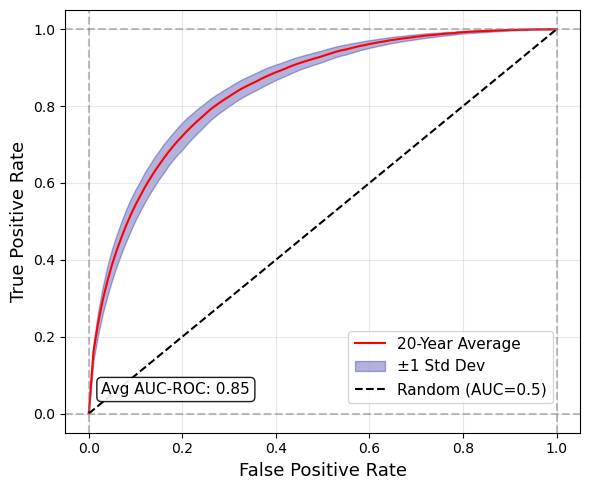

In [7]:
# --- Interpolate per-year ROC curves onto common FPR grid ---------------
common_fpr_points = np.linspace(0, 1, 101)
all_fpr, all_tpr, all_auc_scores = [], [], []

for wy in water_years:
    wy_data = combined[combined["water_year"] == wy]
    fpr, tpr, _ = roc_curve(wy_data["IS_FIRE"].values,
                             wy_data["predictions"].values)
    roc_auc = auc(fpr, tpr)
    all_auc_scores.append(roc_auc)

    interp_tpr = np.interp(common_fpr_points, fpr, tpr)
    all_fpr.append(common_fpr_points)
    all_tpr.append(interp_tpr)

all_fpr = np.array(all_fpr)
all_tpr = np.array(all_tpr)

mean_fpr = np.mean(all_fpr, axis=0)
mean_tpr = np.mean(all_tpr, axis=0)
std_tpr  = np.std(all_tpr,  axis=0)
mean_auc = np.mean(all_auc_scores)
std_auc  = np.std(all_auc_scores)

# --- Plot ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(mean_fpr, mean_tpr,
        color="red", linewidth=1.5, label="20-Year Average")
ax.fill_between(mean_fpr,
                mean_tpr - std_tpr, mean_tpr + std_tpr,
                alpha=0.3, color="darkblue", label="±1 Std Dev")
ax.plot([0, 1], [0, 1], "k--", alpha=1, label="Random (AUC=0.5)")

ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.axhline(y=1, color="gray", linestyle="--", alpha=0.5)
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.5)
ax.axvline(x=1, color="gray", linestyle="--", alpha=0.5)

ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate",  fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(loc=(0.55, 0.07), fontsize=11)
ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])

ax.text(0.07, 0.12, f"Avg AUC-ROC: {mean_auc:.2f}",
        transform=ax.transAxes, fontsize=11, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "ROC_Curve_20yr.png"),
            dpi=300, bbox_inches="tight")
plt.show()

## 6. Precision-Recall Gain Curve (20-Year Average ± 1 Std Dev)

In [8]:
def calculate_pr_gain(y_true, y_scores):
    """Return (recall_gain, precision_gain, thresholds, baseline)."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    baseline = np.sum(y_true) / len(y_true)

    precision_gain = np.where(
        precision > 0,
        (precision - baseline) / ((1 - baseline) * precision + 1e-10), 0)
    recall_gain = np.where(
        recall > 0,
        (recall - baseline) / ((1 - baseline) * recall + 1e-10), 0)

    return (np.clip(recall_gain, -1, 1),
            np.clip(precision_gain, -1, 1),
            thresholds, baseline)

Calculating PRG curves for each water year …
  WY 2001: 127,150 samples, 2,734 fires, baseline=0.0215
  WY 2002: 127,550 samples, 2,757 fires, baseline=0.0216
  WY 2003: 127,270 samples, 2,455 fires, baseline=0.0193
  WY 2004: 127,478 samples, 2,831 fires, baseline=0.0222
  WY 2005: 127,360 samples, 2,343 fires, baseline=0.0184
  WY 2006: 127,296 samples, 2,881 fires, baseline=0.0226
  WY 2007: 126,555 samples, 3,538 fires, baseline=0.0280
  WY 2008: 126,632 samples, 3,141 fires, baseline=0.0248
  WY 2009: 126,982 samples, 2,380 fires, baseline=0.0187
  WY 2010: 127,039 samples, 2,027 fires, baseline=0.0160
  WY 2011: 126,814 samples, 1,976 fires, baseline=0.0156
  WY 2012: 126,701 samples, 2,338 fires, baseline=0.0185
  WY 2013: 127,079 samples, 2,098 fires, baseline=0.0165
  WY 2014: 127,256 samples, 2,331 fires, baseline=0.0183
  WY 2015: 127,439 samples, 1,888 fires, baseline=0.0148
  WY 2016: 127,257 samples, 2,006 fires, baseline=0.0158
  WY 2017: 127,226 samples, 2,023 fires, ba

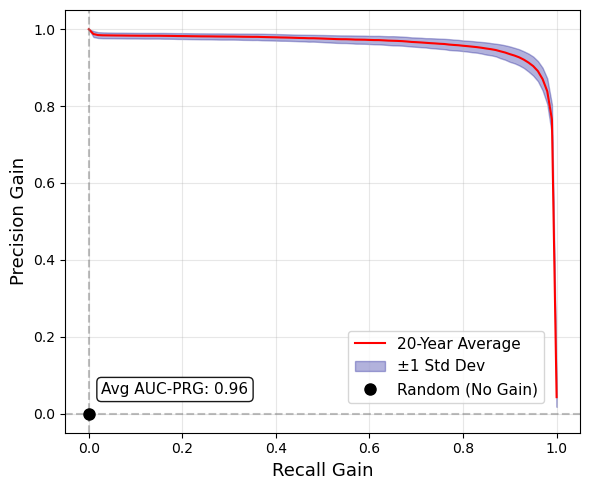

In [9]:
# --- Interpolate per-year PRG curves ------------------------------------
common_recall_points = np.linspace(0, 1, 101)
all_recall_gains, all_precision_gains = [], []

print("Calculating PRG curves for each water year …")
for wy in water_years:
    wy_data = combined[combined["water_year"] == wy]
    rg, pg, _, baseline = calculate_pr_gain(
        wy_data["IS_FIRE"].values, wy_data["predictions"].values)

    idx      = np.argsort(rg)
    rg_sort  = rg[idx]
    pg_sort  = pg[idx]
    uniq     = np.concatenate(([True], rg_sort[1:] != rg_sort[:-1]))
    rg_uniq  = rg_sort[uniq]
    pg_uniq  = pg_sort[uniq]

    if len(rg_uniq) > 1:
        interp_pg = np.interp(common_recall_points, rg_uniq, pg_uniq)
        all_recall_gains.append(common_recall_points)
        all_precision_gains.append(interp_pg)

    print(f"  WY {wy}: {len(wy_data):,} samples, "
          f"{wy_data['IS_FIRE'].sum():,} fires, baseline={baseline:.4f}")

all_recall_gains    = np.array(all_recall_gains)
all_precision_gains = np.array(all_precision_gains)

mean_recall_gain    = np.mean(all_recall_gains,    axis=0)
mean_precision_gain = np.mean(all_precision_gains, axis=0)
std_precision_gain  = np.std(all_precision_gains,  axis=0)

# Per-year AUC-PRG (used again in the time-series plot)
year_aucs_prg = []
for i in range(len(all_precision_gains)):
    mask = all_recall_gains[i] >= 0
    year_aucs_prg.append(np.trapz(all_precision_gains[i][mask],
                                   all_recall_gains[i][mask]))

avg_auc_prg = np.mean(year_aucs_prg)

# --- Plot ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(mean_recall_gain, mean_precision_gain,
        color="red", linewidth=1.5, label="20-Year Average")
ax.fill_between(mean_recall_gain,
                mean_precision_gain - std_precision_gain,
                mean_precision_gain + std_precision_gain,
                alpha=0.3, color="darkblue", label="±1 Std Dev")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.5)
ax.plot(0, 0, "ko", markersize=8, label="Random (No Gain)")

ax.set_xlabel("Recall Gain",    fontsize=13)
ax.set_ylabel("Precision Gain", fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(loc=(0.55, 0.07), fontsize=11)
ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])

ax.text(0.07, 0.12, f"Avg AUC-PRG: {avg_auc_prg:.2f}",
        transform=ax.transAxes, fontsize=11, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "PRG_Curve_20yr.png"),
            dpi=300, bbox_inches="tight")
plt.show()

## 7. AUC Time-Series (per Water Year)

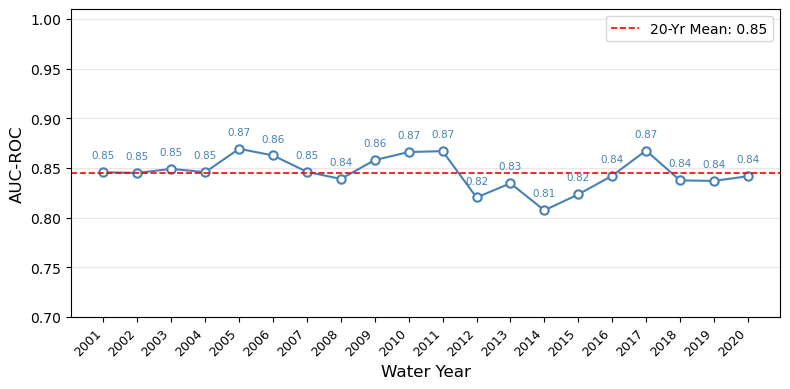

In [10]:
# --- AUC-ROC time-series ------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(water_years, all_auc_scores, color="steelblue", linewidth=1.5,
        marker="o", markersize=6, markerfacecolor="white", markeredgewidth=1.5)
ax.axhline(y=mean_auc, color="red", linestyle="--", linewidth=1.2,
           label=f"20-Yr Mean: {mean_auc:.2f}")

for wy, val in zip(water_years, all_auc_scores):
    ax.annotate(f"{val:.2f}", xy=(wy, val), xytext=(0, 10),
                textcoords="offset points", ha="center",
                fontsize=7.5, color="steelblue")

ax.set_xlabel("Water Year", fontsize=12)
ax.set_ylabel("AUC-ROC",    fontsize=12)
ax.set_xticks(water_years)
ax.set_xticklabels(water_years, rotation=45, ha="right", fontsize=9)
ax.set_ylim([0.7, 1.01])
ax.grid(True, alpha=0.3, axis="y")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "AUC_ROC_TimeSeries.png"),
            dpi=300, bbox_inches="tight")
plt.show()

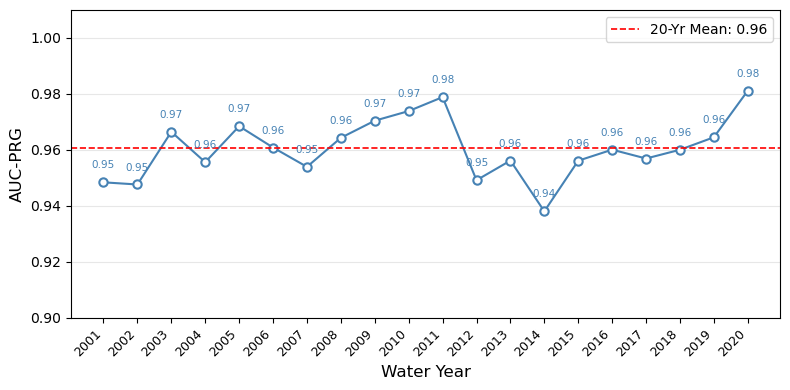

In [11]:
# --- AUC-PRG time-series ------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(water_years, year_aucs_prg, color="steelblue", linewidth=1.5,
        marker="o", markersize=6, markerfacecolor="white", markeredgewidth=1.5)
ax.axhline(y=avg_auc_prg, color="red", linestyle="--", linewidth=1.2,
           label=f"20-Yr Mean: {avg_auc_prg:.2f}")

for wy, val in zip(water_years, year_aucs_prg):
    ax.annotate(f"{val:.2f}", xy=(wy, val), xytext=(0, 10),
                textcoords="offset points", ha="center",
                fontsize=7.5, color="steelblue")

ax.set_xlabel("Water Year", fontsize=12)
ax.set_ylabel("AUC-PRG",    fontsize=12)
ax.set_xticks(water_years)
ax.set_xticklabels(water_years, rotation=45, ha="right", fontsize=9)
ax.set_ylim([0.9, 1.01])
ax.grid(True, alpha=0.3, axis="y")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "AUC_PRG_TimeSeries.png"),
            dpi=300, bbox_inches="tight")
plt.show()

## 8. Precision & Recall Gain at Top 1 % / 5 % Risk Areas

In [12]:
top1_pg, top1_rg = [], []
top5_pg, top5_rg = [], []

for wy in water_years:
    wy_data  = combined[combined["water_year"] == wy]
    y_true   = wy_data["IS_FIRE"].values
    y_scores = wy_data["predictions"].values
    baseline = y_true.sum() / len(y_true)
    total_fire = y_true.sum()

    sort_idx     = np.argsort(y_scores)[::-1]
    y_true_sorted = y_true[sort_idx]

    for pct, pg_list, rg_list in [(0.01, top1_pg, top1_rg),
                                   (0.05, top5_pg, top5_rg)]:
        n  = int(len(y_true) * pct)
        tp = y_true_sorted[:n].sum()
        prec = tp / n          if n > 0          else 0
        rec  = tp / total_fire if total_fire > 0 else 0

        pg = (prec - baseline) / ((1 - baseline) * prec) if prec > 0 else 0
        rg = (rec  - baseline) / ((1 - baseline) * rec)  if rec  > 0 else 0
        pg_list.append(pg)
        rg_list.append(rg)

    print(f"  WY {wy}: "
          f"Top 1 % — PG={top1_pg[-1]:.3f}, RG={top1_rg[-1]:.3f}  |  "
          f"Top 5 % — PG={top5_pg[-1]:.3f}, RG={top5_rg[-1]:.3f}")

# --- Summary ---
for label, pg_vals, rg_vals in [("Top 1 %", top1_pg, top1_rg),
                                 ("Top 5 %", top5_pg, top5_rg)]:
    print(f"\n{label} Risk Area:")
    print(f"  Precision Gain : {np.mean(pg_vals):.3f} ± {np.std(pg_vals):.3f}  "
          f"[{np.min(pg_vals):.3f}, {np.max(pg_vals):.3f}]")
    print(f"  Recall Gain    : {np.mean(rg_vals):.3f} ± {np.std(rg_vals):.3f}  "
          f"[{np.min(rg_vals):.3f}, {np.max(rg_vals):.3f}]")

print(f"\nPR-Gain curve markers:")
print(f"  Top 1 %: (RG={np.mean(top1_rg):.3f}, PG={np.mean(top1_pg):.3f})")
print(f"  Top 5 %: (RG={np.mean(top5_rg):.3f}, PG={np.mean(top5_pg):.3f})")

  WY 2001: Top 1 % — PG=0.941, RG=0.847  |  Top 5 % — PG=0.878, RG=0.960
  WY 2002: Top 1 % — PG=0.933, RG=0.829  |  Top 5 % — PG=0.873, RG=0.958
  WY 2003: Top 1 % — PG=0.944, RG=0.874  |  Top 5 % — PG=0.880, RG=0.966
  WY 2004: Top 1 % — PG=0.941, RG=0.842  |  Top 5 % — PG=0.875, RG=0.957
  WY 2005: Top 1 % — PG=0.950, RG=0.893  |  Top 5 % — PG=0.898, RG=0.974
  WY 2006: Top 1 % — PG=0.953, RG=0.863  |  Top 5 % — PG=0.895, RG=0.965
  WY 2007: Top 1 % — PG=0.955, RG=0.822  |  Top 5 % — PG=0.895, RG=0.954
  WY 2008: Top 1 % — PG=0.954, RG=0.847  |  Top 5 % — PG=0.884, RG=0.955
  WY 2009: Top 1 % — PG=0.953, RG=0.895  |  Top 5 % — PG=0.891, RG=0.971
  WY 2010: Top 1 % — PG=0.954, RG=0.916  |  Top 5 % — PG=0.895, RG=0.978
  WY 2011: Top 1 % — PG=0.956, RG=0.922  |  Top 5 % — PG=0.896, RG=0.978
  WY 2012: Top 1 % — PG=0.933, RG=0.861  |  Top 5 % — PG=0.855, RG=0.958
  WY 2013: Top 1 % — PG=0.934, RG=0.881  |  Top 5 % — PG=0.866, RG=0.967
  WY 2014: Top 1 % — PG=0.919, RG=0.836  |  Top 5 %

---
# Part B — SHAP & Feature Importance

## 9. Helper Functions

In [13]:
def plot_shap_bar(Eval_data, feats, explainer, top_n=25):
    """Compute SHAP values and return top-N mean |SHAP| + correlation."""
    shap_values = explainer(Eval_data[feats])
    shap_df     = pd.DataFrame(shap_values.values, columns=feats)

    top_abs  = shap_df.abs().mean().nlargest(top_n)
    top_cols = top_abs.index

    corr = shap_df[top_cols].reset_index(drop=True).corrwith(
        Eval_data[top_cols].reset_index(drop=True), numeric_only=False)
    top_abs = top_abs.loc[corr.index].sort_values()

    return pd.DataFrame({"mean_abs_shap": top_abs,
                          "corr": corr[top_abs.index]})

In [14]:
def get_base_model(cal_model):
    """Extract the underlying XGBoost estimator from CalibratedClassifierCV."""
    return getattr(cal_model, "estimator",
                   getattr(cal_model, "base_estimator", None))

## 10. Compute SHAP Values (20 years, Area = All, Season = all)

In [15]:
years = range(2001, 2021)

all_shap_values = []
log_messages    = [f"Run started : {pd.Timestamp.now()}", f"Experiment  : {TAG}"]

for yr in tqdm(list(years), desc="SHAP analysis"):
    pkl_path = os.path.join(MODEL_DIR, f"predict_{yr}.pkl")
    if not os.path.exists(pkl_path):
        continue

    with open(pkl_path, "rb") as f:
        loaded_model = pickle.load(f)

    booster        = get_base_model(loaded_model).get_booster()
    model_features = booster.feature_names
    explainer      = shap.Explainer(get_base_model(loaded_model))

    # Use full non-calibration data for this water year (fire events only)
    evl = mod_data[mod_data["water_year"] == yr].copy()
    evl_fire = evl[evl[LABEL_COL] == 1].copy()

    if evl_fire.empty:
        log_messages.append(f"WY {yr}: no fire events — skipped")
        del loaded_model, evl
        gc.collect()
        continue

    shap_result = plot_shap_bar(evl_fire, model_features, explainer, top_n=25)
    shap_result["year"] = yr
    shap_result["area"] = "All"
    all_shap_values.append(shap_result)

    log_messages.append(f"WY {yr}: {len(evl_fire):,} fire events, "
                        f"{len(model_features)} features")

    del loaded_model, evl, evl_fire
    gc.collect()

print(f"\nCollected SHAP from {len(all_shap_values)} water years")

SHAP analysis: 100%|██████████| 20/20 [00:14<00:00,  1.42it/s]


Collected SHAP from 20 water years


## 11. Save SHAP Values

In [16]:
all_shap_values_df = (pd.concat(all_shap_values, ignore_index=False)
                        .reset_index()
                        .rename(columns={"index": "feature"}))

shap_save_dir = os.path.join(SUMMARY_DIR, "Shap_Value")
os.makedirs(shap_save_dir, exist_ok=True)

all_shap_values_df.to_csv(
    os.path.join(shap_save_dir, "shap_values_top_25.csv"), index=False)
with open(os.path.join(shap_save_dir, "log.txt"), "w") as f:
    f.write("\n".join(log_messages))

print(f"Saved to  : {shap_save_dir}")
print(f"SHAP shape: {all_shap_values_df.shape}")

Saved to  : E:\zcao\Ignition - ML Modeling\Summary_Data\E3_pole_tower__LT6\Shap_Value
SHAP shape: (500, 5)


## 12. Extract XGBoost Feature Importance (weight & gain)

In [17]:
all_importances = []

for yr in tqdm(range(2001, 2021), desc="Feature importance"):
    pkl_path = os.path.join(MODEL_DIR, f"predict_{yr}.pkl")
    if not os.path.exists(pkl_path):
        continue

    with open(pkl_path, "rb") as f:
        loaded_model = pickle.load(f)

    booster        = get_base_model(loaded_model).get_booster()
    model_features = booster.feature_names

    # F-score (weight)
    w_dict = booster.get_score(importance_type="weight")
    w = np.array([w_dict.get(f, 0.0) for f in model_features])
    w_pct = 100 * w / w.sum() if w.sum() > 0 else np.zeros_like(w)

    # Gain
    g_dict = booster.get_score(importance_type="gain")
    g = np.array([g_dict.get(f, 0.0) for f in model_features])
    g_pct = 100 * g / g.sum() if g.sum() > 0 else np.zeros_like(g)

    all_importances.append(pd.DataFrame({
        "feature": model_features, "year": yr,
        "relative_importance_weight": w_pct,
        "relative_importance_gain":   g_pct,
    }))
    del loaded_model

feature_importance_all_years = pd.concat(all_importances, ignore_index=True)
print(f"Feature-importance shape: {feature_importance_all_years.shape}")

Feature importance: 100%|██████████| 20/20 [00:00<00:00, 126.81it/s]

Feature-importance shape: (640, 4)


### Save feature importance

In [18]:
fi_save_dir = os.path.join(SUMMARY_DIR, "Feature_Importance")
os.makedirs(fi_save_dir, exist_ok=True)

feature_importance_all_years.to_csv(
    os.path.join(fi_save_dir, "feature_importance_all_years.csv"), index=False)
print(f"Saved to: {fi_save_dir}")

Saved to: E:\zcao\Ignition - ML Modeling\Summary_Data\E3_pole_tower__LT6\Feature_Importance


---
# Part C — Visualisation

## 13. Feature Importance — Horizontal Bar Chart (Top 25)

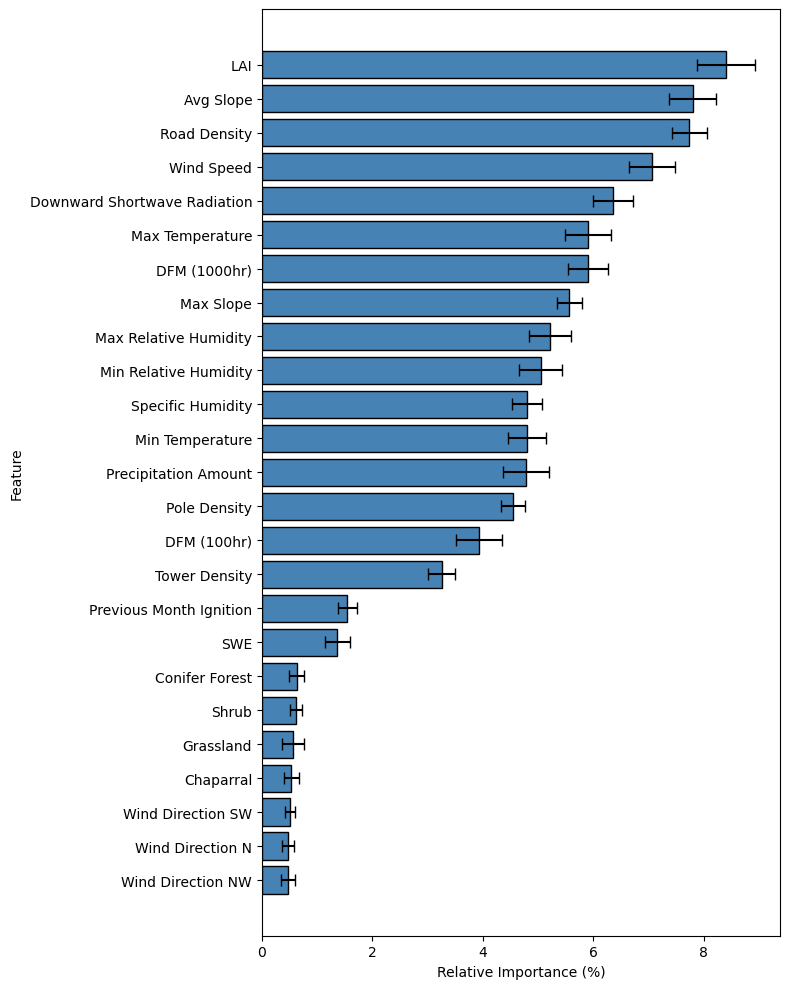

In [19]:
fi_df   = feature_importance_all_years.copy()
n_years = fi_df["year"].nunique()

# Keep only features that appear in every year
counts   = fi_df.groupby("feature")["year"].nunique()
keep     = counts[counts == n_years].index
fi_filt  = fi_df[fi_df["feature"].isin(keep)]

feat_stats = (
    fi_filt.groupby("feature")["relative_importance_weight"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
    .reset_index()
)
feat_stats["feature"]      = feat_stats["feature"].str.strip()
feat_stats["display_name"] = feat_stats["feature"].map(rename_dict).fillna(
                                 feat_stats["feature"])

top_n = 25
fs_top = feat_stats.head(top_n)

fig, ax = plt.subplots(figsize=(8, top_n * 0.4))
ax.barh(fs_top["display_name"], fs_top["mean"],
        xerr=fs_top["std"], capsize=4,
        color="steelblue", edgecolor="black")
ax.set_xlabel("Relative Importance (%)")
ax.set_ylabel("Feature")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "Feature_Importance_Top25.png"),
            dpi=300, bbox_inches="tight")
plt.show()

## 14. SHAP Bar Chart (Top 25, Area = All)

Green bars → positive correlation between feature value and SHAP
(higher value → higher fire probability).
Red bars → negative correlation.

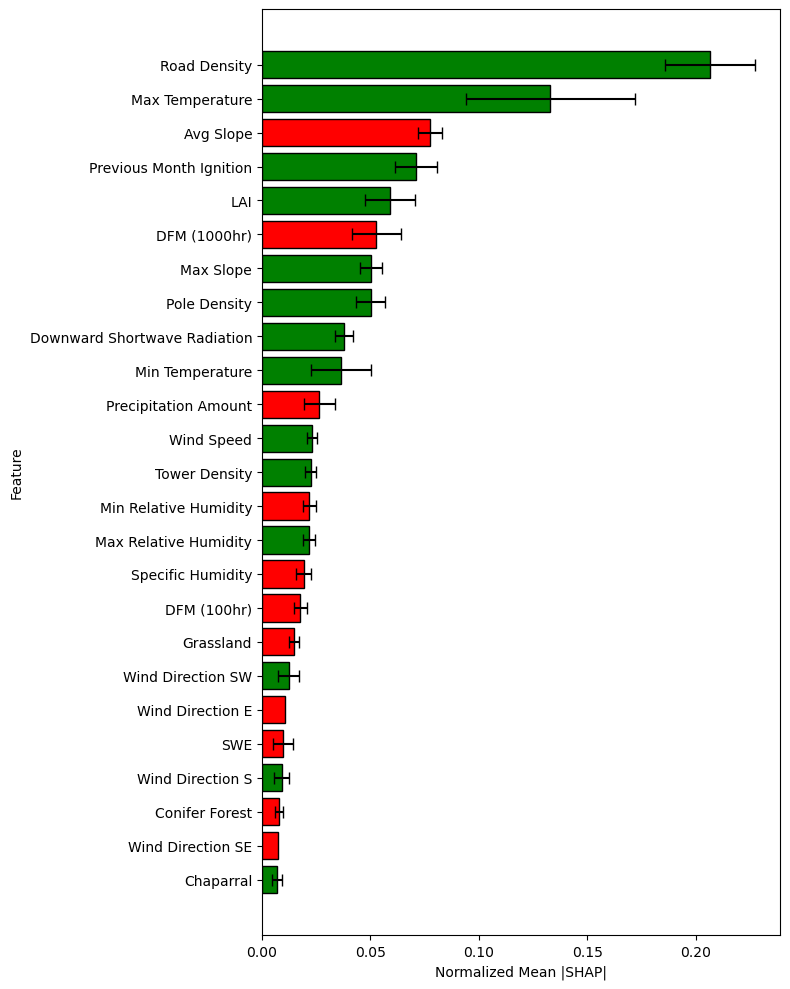

In [20]:
shap_all = all_shap_values_df.copy()
shap_all["feature"] = shap_all["feature"].str.strip()
shap_all["display_name"] = shap_all["feature"].map(rename_dict).fillna(
                               shap_all["feature"])

# Normalise per year
shap_all["norm_shap"] = (
    shap_all.groupby("year")["mean_abs_shap"]
    .transform(lambda x: x / x.sum() if x.sum() != 0 else x)
)

agg = (
    shap_all.groupby(["feature", "display_name"])
    .agg(mean_shap=("norm_shap", "mean"),
         std_shap =("norm_shap", "std"),
         mean_corr=("corr",      "mean"))
    .reset_index()
)
agg["bar_color"] = agg["mean_corr"].apply(lambda x: "green" if x > 0 else "red")

top25 = agg.sort_values("mean_shap", ascending=False).head(25)

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(top25["display_name"], top25["mean_shap"],
        xerr=top25["std_shap"], color=top25["bar_color"],
        edgecolor="black", capsize=4)
ax.set_xlabel("Normalized Mean |SHAP|")
ax.set_ylabel("Feature")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "SHAP_Bar_Top25.png"),
            dpi=300, bbox_inches="tight")
plt.show()

## 15. SHAP Heatmap (Top 10 Features × Water Year)

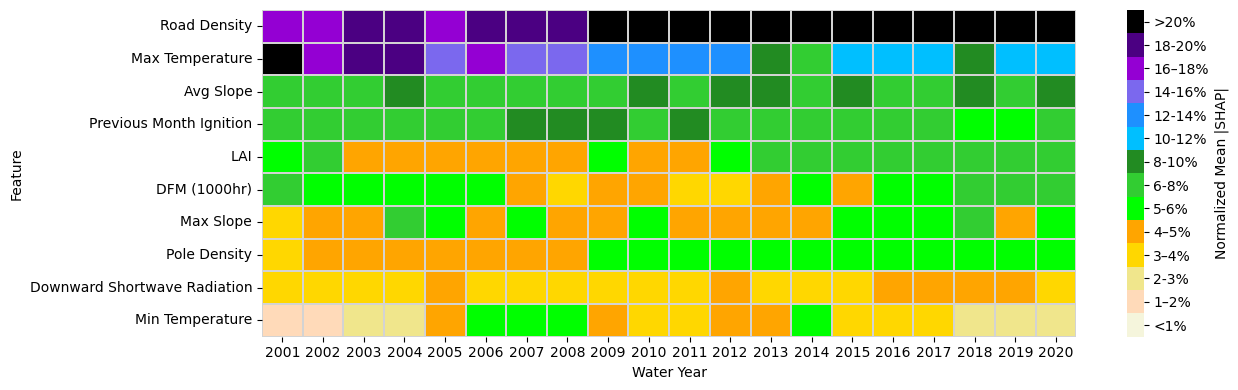


Top 10 features (area = All):
   1. Road Density                   (avg: 0.206)
   2. Max Temperature                (avg: 0.133)
   3. Avg Slope                      (avg: 0.078)
   4. Previous Month Ignition        (avg: 0.071)
   5. LAI                            (avg: 0.059)
   6. DFM (1000hr)                   (avg: 0.053)
   7. Max Slope                      (avg: 0.050)
   8. Pole Density                   (avg: 0.050)
   9. Downward Shortwave Radiation   (avg: 0.038)
  10. Min Temperature                (avg: 0.036)


In [24]:
shap_hm = all_shap_values_df.copy()
shap_hm["feature"] = shap_hm["feature"].str.strip()

shap_hm["norm_shap"] = (
    shap_hm.groupby("year")["mean_abs_shap"]
    .transform(lambda x: x / x.sum() if x.sum() != 0 else x)
)

top_n = 10

# --- Custom colour bins --------------------------------------------------
bin_edges = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16, 0.18, 0.20, 1.0]
custom_colors = [
    "beige", "peachpuff", "khaki", "gold", "orange", "lime", "limegreen", "forestgreen",
    "deepskyblue", "dodgerblue", "mediumslateblue",
    "darkviolet", "indigo", "black"
]
cmap = ListedColormap(custom_colors)
norm = BoundaryNorm(bin_edges, ncolors=len(custom_colors))

tick_labels = ["<1%",  "1–2%", "2-3%", "3–4%", "4–5%", "5-6%", "6-8%",
               "8-10%", "10-12%",  "12-14%", "14-16%",  "16–18%",  "18-20%", ">20%"]

# --- Pivot top features --------------------------------------------------
top_feats = (shap_hm.groupby("feature")["norm_shap"]
             .mean().nlargest(top_n).index.tolist())

pivot = (shap_hm[shap_hm["feature"].isin(top_feats)]
         .groupby(["feature", "year"])["norm_shap"].mean().reset_index()
         .pivot(index="feature", columns="year", values="norm_shap")
         .fillna(0)
         .reindex(top_feats))
pivot.rename(index=lambda x: rename_dict.get(x, x), inplace=True)

# --- Plot ----------------------------------------------------------------
plt.figure(figsize=(13, max(4, 0.4 * top_n)))
ax = sns.heatmap(pivot, cmap=cmap, norm=norm,
                 cbar_kws={"label": "Normalized Mean |SHAP|"},
                 linewidths=0.3, linecolor="lightgray")
ax.set_xlabel("Water Year")
ax.set_ylabel("Feature")
plt.yticks(rotation=0)
plt.xticks(rotation=0, ha="center")

cbar = ax.collections[0].colorbar
cbar.set_ticks([(bin_edges[i] + bin_edges[i+1]) / 2
                for i in range(len(custom_colors))])
cbar.set_ticklabels(tick_labels)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "SHAP_Heatmap_Top10.png"),
            dpi=300, bbox_inches="tight")
plt.show()

# --- Print summary -------------------------------------------------------
print(f"\nTop {top_n} features (area = All):")
for i, feat in enumerate(top_feats, 1):
    avg = shap_hm.loc[shap_hm["feature"] == feat, "norm_shap"].mean()
    print(f"  {i:2d}. {rename_dict.get(feat, feat):<30s} (avg: {avg:.3f})")

## 16. SHAP Dependence Plots (WY 2001 & 2020)

For every feature, plot mean SHAP ± 1 std across binned feature values.
Uses fire events only (Area = All, Season = all).

In [25]:
def bin_shap_dependence(feature_values, shap_values, num_bins=20,
                        if_bin=True, bin_method="quantile"):
    """Bin feature values and compute mean ± std SHAP per bin."""
    if if_bin:
        if bin_method == "quantile":
            bins = np.unique(
                np.quantile(feature_values.dropna(),
                            np.linspace(0, 1, num_bins + 1)))
        else:
            bins = np.linspace(feature_values.min(),
                               feature_values.max(), num_bins + 1)
        digitized   = np.clip(np.digitize(feature_values, bins) - 1,
                              0, len(bins) - 2)
        bin_centers = (bins[:-1] + bins[1:]) / 2
    else:
        unique_vals = np.sort(feature_values.unique())
        digitized   = np.searchsorted(unique_vals, feature_values)
        bin_centers = unique_vals

    mean_s = np.array([np.mean(shap_values[digitized == i])
                       for i in range(len(bin_centers))])
    std_s  = np.array([np.std(shap_values[digitized == i])
                       for i in range(len(bin_centers))])

    valid = ~np.isnan(mean_s)
    return bin_centers[valid], mean_s[valid], std_s[valid]

In [26]:
shap_dep_dir = os.path.join(PLOT_DIR, "SHAP_Dependence")
os.makedirs(shap_dep_dir, exist_ok=True)

for yr in [2001, 2020]:
    pkl_path = os.path.join(MODEL_DIR, f"predict_{yr}.pkl")
    if not os.path.exists(pkl_path):
        print(f"WY {yr}: model not found — skipping")
        continue

    with open(pkl_path, "rb") as f:
        loaded_model = pickle.load(f)

    booster        = get_base_model(loaded_model).get_booster()
    model_features = booster.feature_names
    explainer      = shap.Explainer(get_base_model(loaded_model))

    evl = mod_data[mod_data["water_year"] == yr].copy()
    evl_fire = evl[evl[LABEL_COL] == 1].copy()

    if evl_fire.empty:
        print(f"WY {yr}: no fire events — skipping")
        continue

    sv = explainer(evl_fire[model_features])

    for feat in model_features:
        idx    = model_features.index(feat)
        shap_v = sv.values[:, idx]
        feat_v = evl_fire[feat]
        n_uniq = feat_v.nunique()

        if n_uniq <= 20:
            bc, ms, ss = bin_shap_dependence(feat_v, shap_v,
                                              num_bins=n_uniq, if_bin=False)
        elif feat == "SWE":
            bc, ms, ss = bin_shap_dependence(feat_v, shap_v,
                                              num_bins=20, if_bin=True,
                                              bin_method="uniform")
        else:
            bc, ms, ss = bin_shap_dependence(feat_v, shap_v, num_bins=20)

        plt.figure(figsize=(7, 5))
        plt.plot(bc, ms, color="blue", label="Mean SHAP")
        plt.fill_between(bc, ms - ss, ms + ss,
                         color="blue", alpha=0.2, label="Mean ± std")
        plt.xlabel(rename_dict.get(feat, feat))
        plt.ylabel("SHAP value")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(shap_dep_dir, f"{feat}_{yr}.png"),
                    dpi=300, bbox_inches="tight")
        plt.close()

    print(f"WY {yr}: saved {len(model_features)} dependence plots")
    del loaded_model, evl, evl_fire
    gc.collect()

WY 2001: saved 32 dependence plots
WY 2020: saved 32 dependence plots


---
## Summary

All outputs have been saved.  Run the cell below to list generated files.

In [27]:
print(f"Plot directory    : {PLOT_DIR}")
print(f"Summary directory : {SUMMARY_DIR}")

print("\nGenerated files:")
for root, dirs, files in os.walk(PLOT_DIR):
    level = root.replace(PLOT_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for fname in sorted(files):
        print(f"{indent}  {fname}")

Plot directory    : E:\zcao\Ignition - ML Modeling\Plots\E3_pole_tower__LT6
Summary directory : E:\zcao\Ignition - ML Modeling\Summary_Data\E3_pole_tower__LT6

Generated files:
E3_pole_tower__LT6/
  AUC_PRG_TimeSeries.png
  AUC_ROC_TimeSeries.png
  Feature_Importance_Top25.png
  PRG_Curve_20yr.png
  ROC_Curve_20yr.png
  SHAP_Bar_Top25.png
  SHAP_Heatmap_Top10.png
  SHAP_Dependence/
    LAI_2001.png
    LAI_2020.png
    SWE_2001.png
    SWE_2020.png
    dead_fuel_moisture_1000hr_2001.png
    dead_fuel_moisture_1000hr_2020.png
    dead_fuel_moisture_100hr_2001.png
    dead_fuel_moisture_100hr_2020.png
    max_air_temperature_2001.png
    max_air_temperature_2020.png
    max_relative_humidity_2001.png
    max_relative_humidity_2020.png
    min_air_temperature_2001.png
    min_air_temperature_2020.png
    min_relative_humidity_2001.png
    min_relative_humidity_2020.png
    pole_density_2001.png
    pole_density_2020.png
    precipitation_amount_2001.png
    precipitation_amount_2020.png
 